In [ ]:
from google.colab import files
import pandas as pd

# Upload the Excel file
uploaded = files.upload()

# Read the Excel file into a pandas DataFrame
for filename in uploaded.keys():
  # Assuming the first sheet is named 'Sheet1'
  sdf = pd.read_csv(filename, sep='\t')
# Display the DataFrame (optional)
print(sdf.head())

Saving Real_time_dataset(123).csv to Real_time_dataset(123) (2).csv
        Date   Hum  Temp    pressure  mintemp  maxtemp
0  04-Nov-24  79.0  30.2  1008.62531     20.0     21.6
1  05-Nov-24  77.0  29.8  1008.61737     19.5     23.8
2  06-Nov-24  78.0  29.9  1008.62201     23.0     23.4
3  07-Nov-24  80.0  30.8  1008.61108     23.4     23.0
4  13-Nov-24  81.0  31.3  1008.59741     21.1     24.0


In [ ]:
print(sdf['Date'].dtype)

object


In [ ]:
# Ensure the 'Date' column is in datetime format
sdf['Date'] = pd.to_datetime(sdf['Date'])

# Verify the data type change
print(sdf['Date'].dtype)

datetime64[ns]


<ipython-input-7-6f6ede62f533>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sdf['Date'] = pd.to_datetime(sdf['Date'])


In [ ]:
from google.colab import files
import pandas as pd

# Upload the Excel file
uploaded = files.upload()

# Read the Excel file into a pandas DataFrame
for filename in uploaded.keys():
  # Assuming the first sheet is named 'Sheet1'
  df = pd.read_csv(filename)
arima_df=df.copy()
# Display the DataFrame
print(df.head())

Saving Kolkata_weather_data(2017-2022).csv to Kolkata_weather_data(2017-2022).csv
                     Address   Date time  Minimum Temperature  \
0  Kolkata,West Bengal,India  01-01-2017                 14.0   
1  Kolkata,West Bengal,India  01-02-2017                 16.0   
2  Kolkata,West Bengal,India  01-03-2017                 16.0   
3  Kolkata,West Bengal,India  01-04-2017                 16.0   
4  Kolkata,West Bengal,India  01-05-2017                 15.0   

   Maximum Temperature  Temperature  Dew Point  Relative Humidity  Heat Index  \
0                 25.3         19.9       16.5              82.47         NaN   
1                 26.0         20.6       16.0              76.76         NaN   
2                 27.0         21.1       15.6              73.12        27.3   
3                 25.0         19.9       14.5              72.57         NaN   
4                 25.6         19.6       13.7              71.88         NaN   

   Wind Speed  Wind Gust  ...  Visibilit

In [ ]:
print(df.size)
print(arima_df.shape)

54775
(2191, 25)


In [ ]:
import pandas as pd

# Define start and end dates
start_date = '2017-01-01'
end_date = '2022-12-31'

# Generate date range
date_range = pd.date_range(start=start_date, end=end_date)

# Assuming your DataFrame is named 'df'
df['Date'] = date_range
#arima_df['Date']=date_range
# Verify the data type
print(df['Date'].dtype)

datetime64[ns]


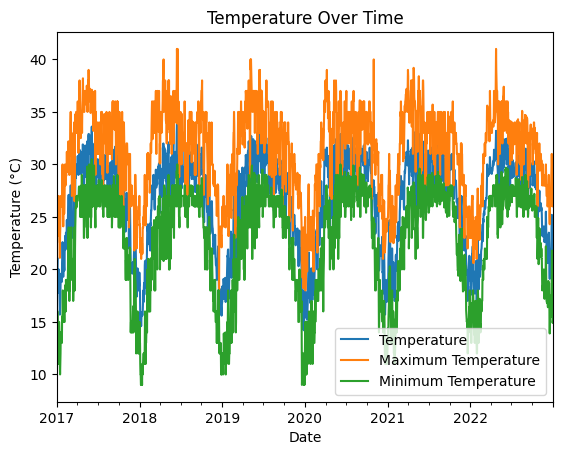

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# --- Ensure 'Date' column is in datetime format and set as index ---
#df['Date'] = pd.to_datetime(df['Date']) # Convert to datetime if not already
df.set_index('Date', inplace=True)    # Set 'Date' as the index

df[['Temperature','Maximum Temperature','Minimum Temperature']].plot(kind='line')

plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend(loc='best') # Legend will show 'Temperature'

# Display the chart
plt.show()

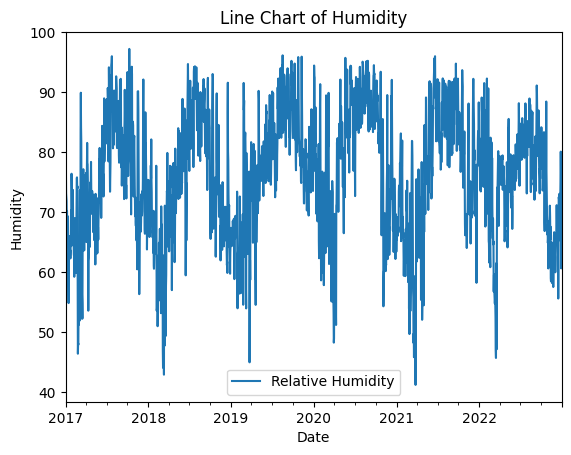

In [ ]:
#df['Date'] = pd.to_datetime(df['Date']) # Convert to datetime if not already
#df.set_index('Date', inplace=True)    # Set 'Date' as the index


df['Relative Humidity'].plot(kind='line')

# Customize the chart (optional)
plt.title('Line Chart of Humidity')
plt.xlabel('Date')
plt.ylabel('Humidity')
plt.legend(loc='best')

# Set y-axis range
#plt.ylim(0, 100)

# Set x-axis range (up to the index)
#plt.xlim(0, len(df.index) -1)

# Display the chart
plt.show()

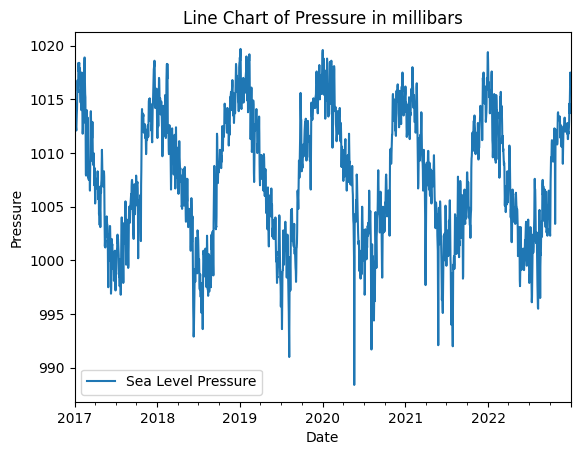

In [ ]:
df['Sea Level Pressure'].plot(kind='line')

# Customize the chart (optional)
plt.title('Line Chart of Pressure in millibars')
plt.xlabel('Date')
plt.ylabel('Pressure')
plt.legend(loc='best')

# Set y-axis range
#plt.ylim(800, 1100)

# Set x-axis range (up to the index)
#plt.xlim(0, len(df.index) -1)

# Display the chart
plt.show()

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

columns_to_impute = ['Maximum Temperature', 'Minimum Temperature', 'Relative Humidity', 'Sea Level Pressure']

imputer = KNNImputer(n_neighbors=5)  # You can adjust the number of neighbors
df[columns_to_impute] = imputer.fit_transform(arima_df[columns_to_impute])
arima_df[columns_to_impute] = imputer.fit_transform(arima_df[columns_to_impute])

# Check for remaining missing values (should be 0)
for column in columns_to_impute:
  print(f"Missing values in '{column}': {arima_df[column].isnull().sum()}")
  print(f"Missing values in '{column}': {df[column].isnull().sum()}")

Missing values in 'Maximum Temperature': 0
Missing values in 'Maximum Temperature': 0
Missing values in 'Minimum Temperature': 0
Missing values in 'Minimum Temperature': 0
Missing values in 'Relative Humidity': 0
Missing values in 'Relative Humidity': 0
Missing values in 'Sea Level Pressure': 0
Missing values in 'Sea Level Pressure': 0


In [ ]:
!pip install prophet

In [ ]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np

# Assuming you have your prophet_df prepared as in your notebook
prophet_df = df.copy().reset_index().rename(columns={'Date': 'ds', 'Maximum Temperature': 'y'})
prophet_df['MinTemp'] = prophet_df['Minimum Temperature']
prophet_df['Humidity'] = prophet_df['Relative Humidity']
prophet_df['Pressure'] = prophet_df['Sea Level Pressure']
prophet_df = prophet_df[['ds', 'y', 'MinTemp', 'Humidity', 'Pressure']]

# Step 1: Split data into training and testing sets
train_size = int(len(prophet_df) * 0.8) # Use the same split as your ARIMA model
train_prophet_df, test_prophet_df = prophet_df.iloc[:train_size], prophet_df.iloc[train_size:]

# Step 2: Train Prophet on the training data
model_prophet = Prophet()
model_prophet.add_regressor('MinTemp')
model_prophet.add_regressor('Humidity')
model_prophet.add_regressor('Pressure')
model_prophet.fit(train_prophet_df)

# Step 3: Make predictions on the test data's 'ds' values
# Create a future DataFrame with only the test dates
future_prophet = pd.DataFrame(test_prophet_df['ds'])
future_prophet.columns = ['ds'] # Ensure the column name is 'ds'

# Add the regressors to the future DataFrame by merging with the test_prophet_df
future_prophet = pd.merge(future_prophet, test_prophet_df[['ds', 'MinTemp', 'Humidity', 'Pressure']], on='ds', how='left')

# Make predictions
forecast_prophet = model_prophet.predict(future_prophet)

# Step 4: Merge predictions with actual values
# We need to align the forecast with the actual test data
forecast_prophet = forecast_prophet[['ds', 'yhat']]
comparison_df = pd.merge(test_prophet_df[['ds', 'y']], forecast_prophet, on='ds', how='left')

# Step 5: Calculate RMSE
# Ensure there are no missing values after merging (shouldn't be if dates align)
comparison_df.dropna(inplace=True)

# Calculate Mean Squared Error (MSE)
mse_prophet = mean_squared_error(comparison_df['y'], comparison_df['yhat'])
print(f'Mean Squared Error (MSE) for Prophet: {mse_prophet}')

# Calculate Root Mean Squared Error (RMSE)
rmse_prophet = np.sqrt(mse_prophet)
print(f'Root Mean Squared Error (RMSE) for Prophet: {rmse_prophet}')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/obcoju3s.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/wi9jih_1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=92571', 'data', 'file=/tmp/tmp6mm4_nvm/obcoju3s.json', 'init=/tmp/tmp6mm4_nvm/wi9jih_1.json', 'output', 'file=/tmp/tmp6mm4_nvm/prophet_modelmfx_hmde/prophet_model-20250524061145.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:11:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:11:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Mean Squared Error (MSE) for Prophet: 2.03783091629096
Root Mean Squared Error (RMSE) for Prophet: 1.4275261525768836


In [ ]:
from statsmodels.tsa.stattools import adfuller


# Extract the 'Maximum Temperature' column
max_temp_series = df['Maximum Temperature']

# Perform the Augmented Dickey-Fuller test
result = adfuller(max_temp_series)

# Print the results
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the results
if result[1] <= 0.05:
    print("The time series is likely stationary.")
else:
    print("The time series is likely non-stationary.")

ADF Statistic: -3.637264279883326
p-value: 0.005087300913566833
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
The time series is likely stationary.


In [ ]:
train_size = int(len(arima_df) * 0.8)  # 80% for training
train_data, test_data = arima_df.iloc[:train_size], arima_df.iloc[train_size:]

# Display the shapes of the training and testing sets (optional)
print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (1752, 25)
Testing data shape: (439, 25)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA


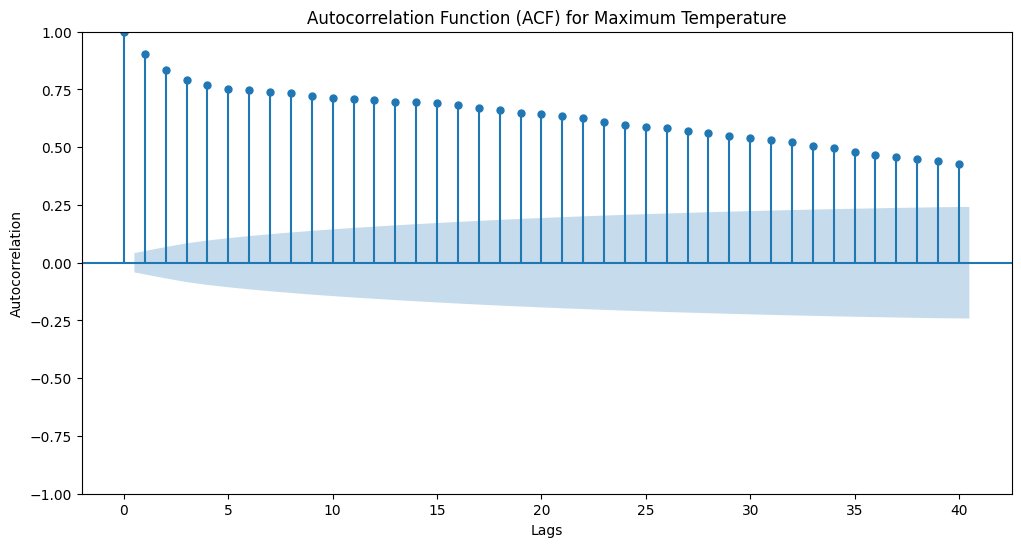

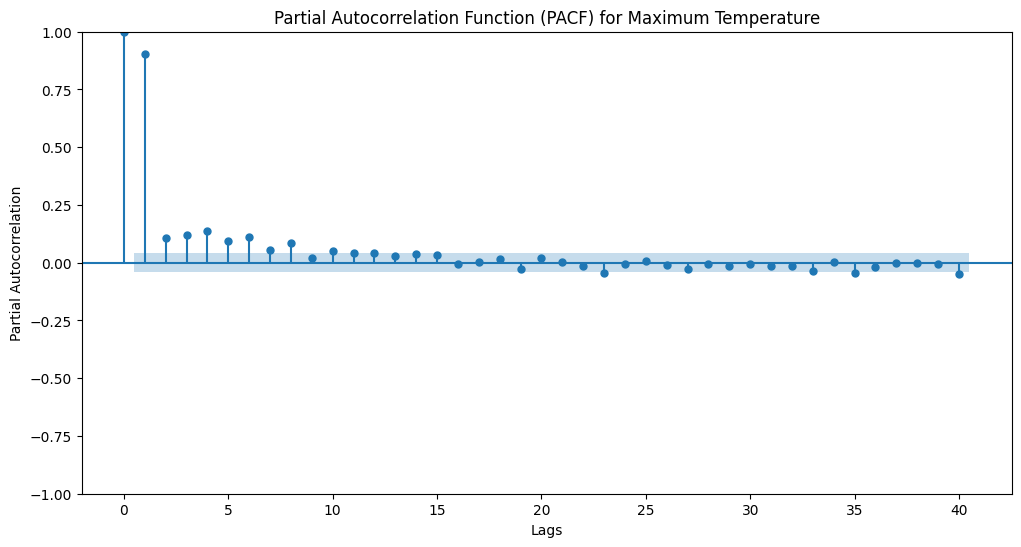

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

max_temp_series = df['Maximum Temperature']

# Plot ACF
plt.figure(figsize=(12, 6))
plot_acf(max_temp_series, lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) for Maximum Temperature')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# Plot PACF
plt.figure(figsize=(12, 6))
plot_pacf(max_temp_series, lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) for Maximum Temperature')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

In [ ]:
# Define the ARIMA order (p, d, q)
# You will need to determine the appropriate order based on your data analysis (e.g., ACF and PACF plots)
# For this example, we'll use a placeholder order.
order = (2, 0, 0)


In [ ]:
# Extract the 'Maximum Temperature' series from the training data
train_series = train_data['Maximum Temperature']
test_series = test_data['Maximum Temperature']

In [ ]:
# Create and fit the ARIMA model
model = ARIMA(train_series, order=order)
model_fit = model.fit()

# Print the model summary (optional)
print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     Maximum Temperature   No. Observations:                 1752
Model:                  ARIMA(2, 0, 0)   Log Likelihood               -3550.440
Date:                 Sat, 24 May 2025   AIC                           7108.880
Time:                         06:16:13   BIC                           7130.754
Sample:                              0   HQIC                          7116.965
                                - 1752                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.5320      0.498     63.277      0.000      30.555      32.509
ar.L1          0.8013      0.020     39.993      0.000       0.762       0.841
ar.L2          0.1073      0.020      5.450 

In [ ]:
# Make predictions on the test data
start_index = len(train_series)
end_index = len(arima_df) - 1  # Predict up to the end of the original arima_df

predictions = model_fit.predict(start=start_index, end=end_index)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(test_series, predictions)
print(f'Mean Squared Error (MSE): {mse}')

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

Mean Squared Error (MSE): 15.68414394679691
Root Mean Squared Error (RMSE): 3.960321192377824


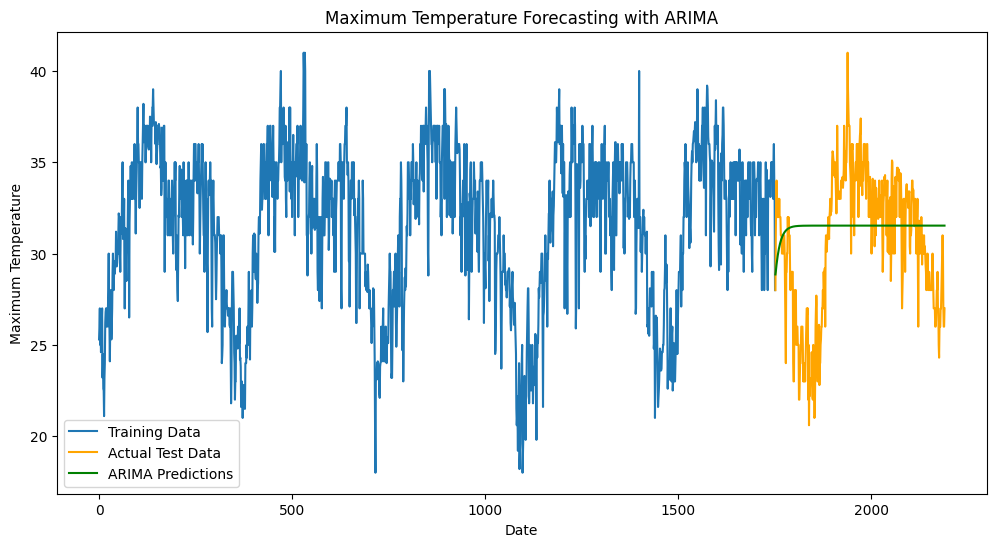

In [ ]:
# Plot actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label='Training Data')
plt.plot(test_series.index, test_series, label='Actual Test Data', color='orange')
plt.plot(predictions.index, predictions, label='ARIMA Predictions', color='green')
plt.title('Maximum Temperature Forecasting with ARIMA')
plt.xlabel('Date')
plt.ylabel('Maximum Temperature')
plt.legend()
plt.show()

In [ ]:
selected_columns=['Maximum Temperature','Minimum Temperature','Relative Humidity','Sea Level Pressure']
new_df=df[selected_columns]
#new_df['Date'] = pd.to_datetime(new_df['Date'])
#new_df.set_index('Date', inplace=True)
print(new_df.head())

            Maximum Temperature  Minimum Temperature  Relative Humidity  \
Date                                                                      
2017-01-01                 25.3                 14.0              82.47   
2017-01-02                 26.0                 16.0              76.76   
2017-01-03                 27.0                 16.0              73.12   
2017-01-04                 25.0                 16.0              72.57   
2017-01-05                 25.6                 15.0              71.88   

            Sea Level Pressure  
Date                            
2017-01-01              1015.9  
2017-01-02              1015.6  
2017-01-03              1014.7  
2017-01-04              1014.6  
2017-01-05              1013.7  


Shape of training features: (1746, 7)
Shape of testing features: (437, 7)
Shape of training target: (1746,)
Shape of testing target: (437,)
Mean Squared Error (MSE) for Random Forest: 3.2702498421052666
Root Mean Squared Error (RMSE) for Random Forest: 1.8083832121829893


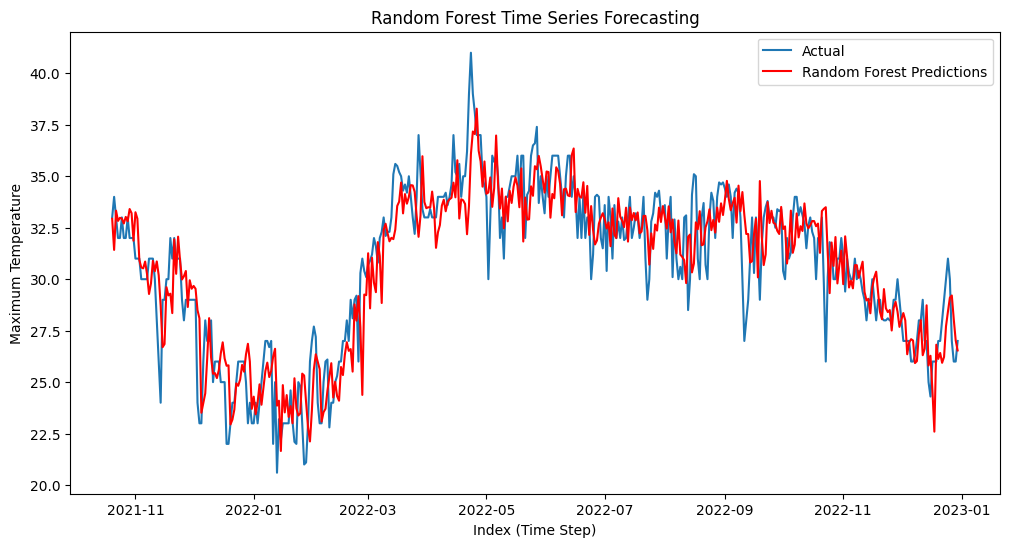

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Step 1: Prepare the data with lagged features

def create_lagged_features(dataframe, column_name, n_lags):
    df_lagged = pd.DataFrame(dataframe[column_name])
    for i in range(1, n_lags + 1):
        df_lagged[f'{column_name}_lag_{i}'] = df_lagged[column_name].shift(i)
    # Shift the original column to be the target variable (predicting the next day's value)
    df_lagged['target'] = df_lagged[column_name].shift(-1)
    df_lagged.dropna(inplace=True) # Drop rows with NaN values introduced by shifting
    return df_lagged

# Define the column to forecast and the number of lags
target_column = 'Maximum Temperature'
n_lags = 7 # You can adjust the number of lags

# Create the lagged dataset
lagged_df = create_lagged_features(new_df, target_column, n_lags)

# Define features (X) and target (y)
X = lagged_df.drop(target_column, axis=1)
X = X.drop('target', axis=1) # Drop the target column itself
y = lagged_df['target']

# Ensure the columns in X are in a consistent order
#feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) # Use shuffle=False for time series

print("Shape of training features:", X_train.shape)
print("Shape of testing features:", X_test.shape)
print("Shape of training target:", y_train.shape)
print("Shape of testing target:", y_test.shape)


# Step 3: Train the Random Forest model

# Initialize the Random Forest Regressor model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model to the training data
model_rf.fit(X_train, y_train)

# Step 4: Make predictions

# Make predictions on the test data
predictions_rf = model_rf.predict(X_test)

# Step 5: Evaluate the model

# Calculate Mean Squared Error (MSE)
mse_rf = mean_squared_error(y_test, predictions_rf)
print(f'Mean Squared Error (MSE) for Random Forest: {mse_rf}')

# Calculate Root Mean Squared Error (RMSE)
rmse_rf = np.sqrt(mse_rf)
print(f'Root Mean Squared Error (RMSE) for Random Forest: {rmse_rf}')

# Optional: Plot actual vs. predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, predictions_rf, label='Random Forest Predictions', color='red')
plt.title('Random Forest Time Series Forecasting')
plt.xlabel('Index (Time Step)') # Note: The index here is not date if you didn't set it as index
plt.ylabel(target_column)
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

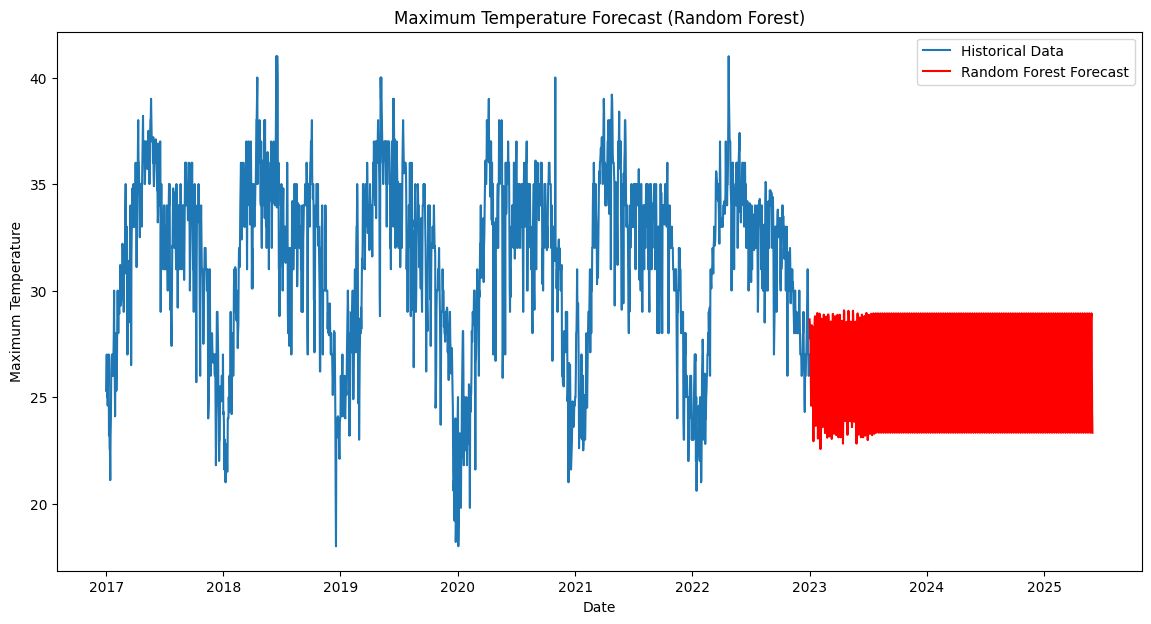

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and contains 'Maximum Temperature'
# And you have already trained your RandomForestRegressor model (model_rf)
# and defined target_column and n_lags

# Step 1: Prepare the data for forecasting

# Start with the last 'n_lags' observations from your original data
# These will be the initial lags for the first forecast step
last_n_lags = new_df[target_column].tail(n_lags).tolist()

# Create a list to store the future forecasts
future_forecasts = []

# Step 2: Implement recursive forecasting

# We will forecast for 882 days
n_forecast_steps = 882

for _ in range(n_forecast_steps):
    # Create the input features for the current forecasting step
    # This will be a single row with the last 'n_lags' values
    input_features = np.array(last_n_lags).reshape(1, -1)

    # Make the prediction for the next time step
    next_prediction = model_rf.predict(input_features)[0]

    # Append the prediction to the list of future forecasts
    future_forecasts.append(next_prediction)

    # Update the 'last_n_lags' list for the next forecasting step
    # Remove the oldest lag and add the new prediction
    last_n_lags.pop(0)
    last_n_lags.append(next_prediction)

# Step 3: Create a DataFrame for the future forecasts

# Generate future dates
# Assuming your original df has a DatetimeIndex or you can create dates based on the end of your data
# If your df has a DatetimeIndex:
if isinstance(new_df.index, pd.DatetimeIndex):
    last_date = new_df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_forecast_steps, freq='D')
else:
    # If your index is not datetime, you might need to create dates differently
    # For simplicity, let's just use a range starting from the end of the current index
    last_index = new_df.index[-1]
    future_indices = range(last_index + 1, last_index + 1 + n_forecast_steps)
    future_dates = future_indices # Or create datetime objects if possible


future_forecast_df = pd.DataFrame({'Date': future_dates, target_column: future_forecasts})

# Optional: Set 'Date' as the index if you created datetime objects
if isinstance(future_dates, pd.DatetimeIndex):
    future_forecast_df.set_index('Date', inplace=True)

# Print the future forecasts
#print(future_forecast_df.head())
#print(future_forecast_df.tail())

# Optional: Plot the historical data and the future forecasts
plt.figure(figsize=(14, 7))
plt.plot(df.index, df[target_column], label='Historical Data')
plt.plot(future_forecast_df.index, future_forecast_df[target_column], label='Random Forest Forecast', color='red')
plt.title(f'{target_column} Forecast (Random Forest)')
plt.xlabel('Date')
plt.ylabel(target_column)
plt.legend()
plt.show()

In [ ]:
from prophet import Prophet


# Prepare data for Prophet
# Create a copy of the DataFrame to avoid modifying the original df in place
prophet_df = df.copy()

# Reset the index to make 'Date' a regular column again
prophet_df = prophet_df.reset_index()

# Rename columns for Prophet
prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Maximum Temperature': 'y'})  # Prophet expects 'ds' and 'y' columns

# Add other features as regressors to the Prophet DataFrame
prophet_df['MinTemp'] = prophet_df['Minimum Temperature']
prophet_df['Humidity'] = prophet_df['Relative Humidity']
prophet_df['Pressure'] = prophet_df['Sea Level Pressure']

# Select only the required columns for Prophet
prophet_df = prophet_df[['ds', 'y', 'MinTemp', 'Humidity', 'Pressure']]


# Create and train the model
model = Prophet()
model.add_regressor('MinTemp')
model.add_regressor('Humidity')
model.add_regressor('Pressure')
model.fit(prophet_df) # Fit the model using the prepared DataFrame

# Create future dates for forecasting
future = model.make_future_dataframe(periods=882)  # Forecast for the next 2.5 year

# Add the regressors to the future DataFrame by merging with the prophet_df
future = pd.merge(future, prophet_df[['ds', 'MinTemp', 'Humidity', 'Pressure']], on='ds', how='left')

# Fill NaN values in the future DataFrame with the mean of the respective columns from prophet_df
future = future.fillna(prophet_df[['MinTemp', 'Humidity', 'Pressure']].mean())

# Make predictions
forecast = model.predict(future)


# Access forecast values
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))  # View the last 30 days

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/m4be3a11.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/nyg936as.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28951', 'data', 'file=/tmp/tmp6mm4_nvm/m4be3a11.json', 'init=/tmp/tmp6mm4_nvm/nyg936as.json', 'output', 'file=/tmp/tmp6mm4_nvm/prophet_model7n236h9e/prophet_model-20250524062125.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:21:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:21:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


             ds       yhat  yhat_lower  yhat_upper
3043 2025-05-02  30.275024   28.276578   32.337553
3044 2025-05-03  30.135267   28.047429   32.117101
3045 2025-05-04  30.333498   28.481995   32.306643
3046 2025-05-05  30.261558   28.331094   32.268280
3047 2025-05-06  30.371829   28.451322   32.234522
3048 2025-05-07  30.238417   28.312892   32.276873
3049 2025-05-08  30.207628   28.320386   32.133484
3050 2025-05-09  30.278001   28.412459   32.227998
3051 2025-05-10  30.119673   28.154156   32.078011
3052 2025-05-11  30.300390   28.340331   32.324944
3053 2025-05-12  30.212167   28.275905   32.088688
3054 2025-05-13  30.307546   28.187029   32.346658
3055 2025-05-14  30.160767   28.116502   32.176773
3056 2025-05-15  30.118247   28.220798   32.165504
3057 2025-05-16  30.178603   28.210948   32.225222
3058 2025-05-17  30.012013   27.935282   32.133472
3059 2025-05-18  30.186234   28.258460   32.186397
3060 2025-05-19  30.093254   28.137617   32.140024
3061 2025-05-20  30.185549   28

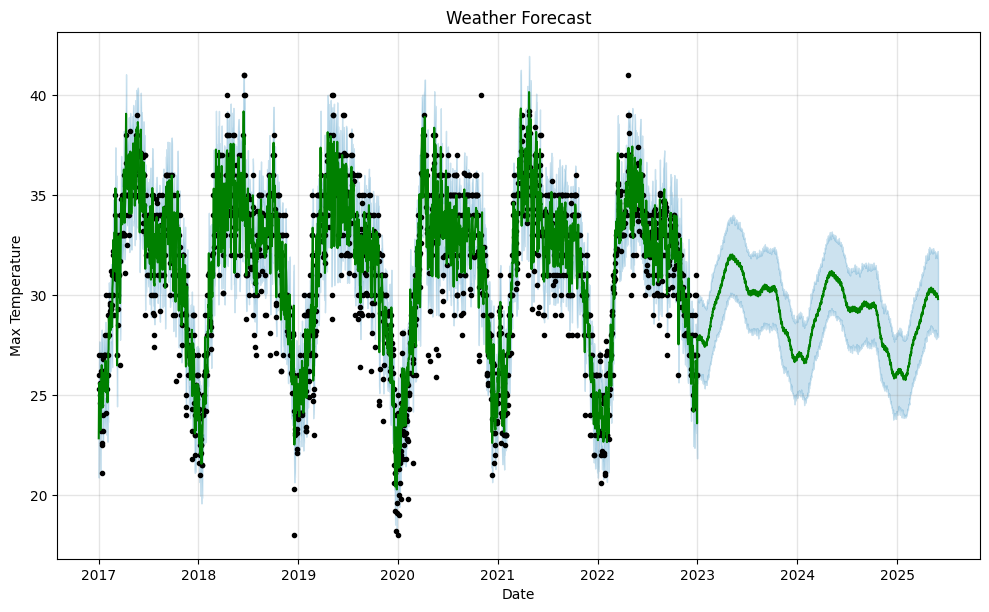

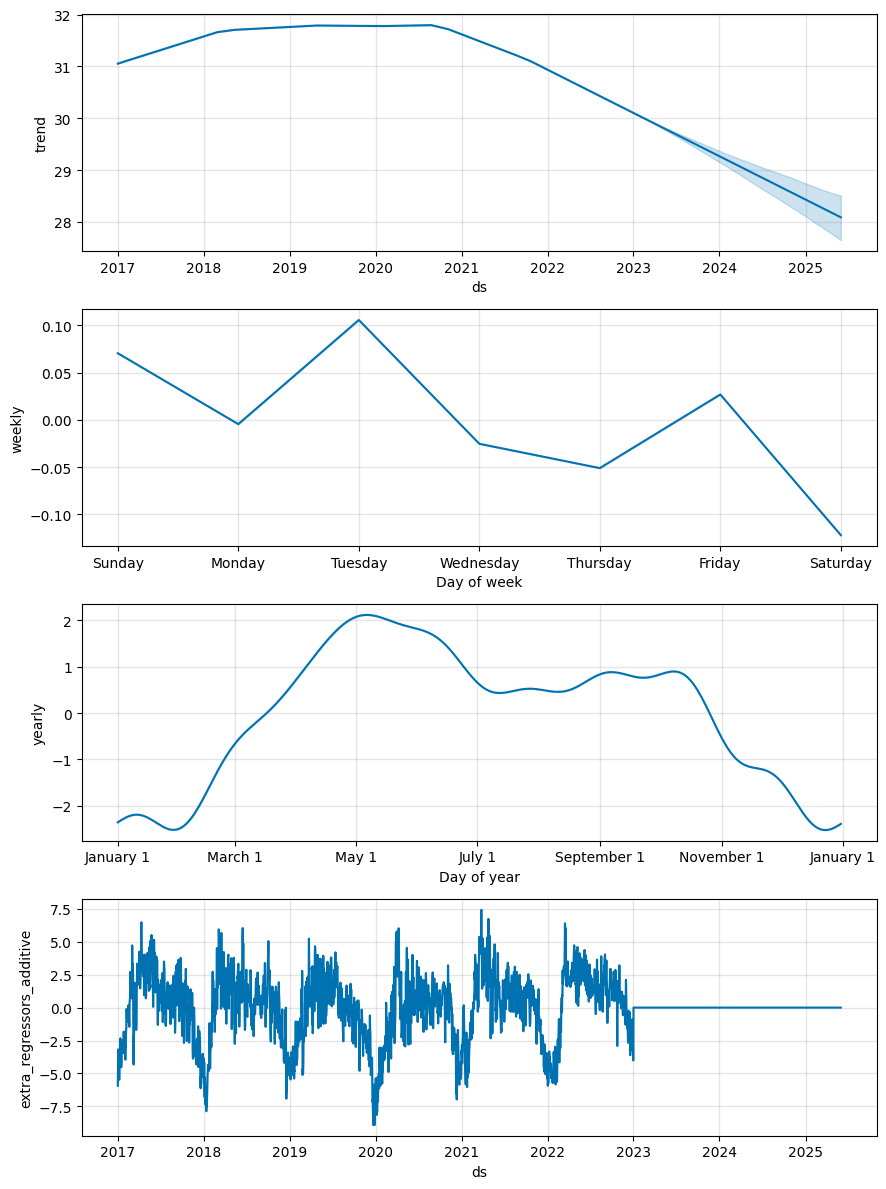

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have the forecast DataFrame from the model

# Plot the forecast
fig = model.plot(forecast)
plt.title('Weather Forecast')
plt.xlabel('Date')
plt.ylabel('Max Temperature')

# Get the line representing the forecast (usually the second line in the plot)
forecast_line = fig.axes[0].lines[1]

# Change the color of the forecast line
forecast_line.set_color('green')
plt.show()

# Plot components (trend, seasonality)
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
from prophet import Prophet


# Prepare data for Prophet
# Create a copy of the DataFrame to avoid modifying the original df in place
prophet_min_df = df.copy()

# Reset the index to make 'Date' a regular column again
prophet_min_df = prophet_min_df.reset_index()

# Rename columns for Prophet
prophet_min_df = prophet_min_df.rename(columns={'Date': 'ds', 'Minimum Temperature': 'y'})  # Prophet expects 'ds' and 'y' columns

# Add other features as regressors to the Prophet DataFrame
prophet_min_df['MaxTemp'] = prophet_min_df['Maximum Temperature']
prophet_min_df['Humidity'] = prophet_min_df['Relative Humidity']
prophet_min_df['Pressure'] = prophet_min_df['Sea Level Pressure']

# Select only the required columns for Prophet
prophet_min_df = prophet_min_df[['ds', 'y', 'MaxTemp', 'Humidity', 'Pressure']]


# Create and train the model
model = Prophet()
model.add_regressor('MaxTemp')
model.add_regressor('Humidity')
model.add_regressor('Pressure')
model.fit(prophet_min_df) # Fit the model using the prepared DataFrame

# Create future dates for forecasting
future_min = model.make_future_dataframe(periods=882)  # Forecast for the next 2.5 year

# Add the regressors to the future DataFrame by merging with the prophet_df
future_min = pd.merge(future_min, prophet_min_df[['ds', 'MaxTemp', 'Humidity', 'Pressure']], on='ds', how='left')

# Fill NaN values in the future DataFrame with the mean of the respective columns from prophet_df
future_min = future_min.fillna(prophet_min_df[['MaxTemp', 'Humidity', 'Pressure']].mean())

# Make predictions
forecast_min = model.predict(future_min)


# Access forecast values
print(forecast_min[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))  # View the last 30 days

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/iya_2xi1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/en2hzcs9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=77535', 'data', 'file=/tmp/tmp6mm4_nvm/iya_2xi1.json', 'init=/tmp/tmp6mm4_nvm/en2hzcs9.json', 'output', 'file=/tmp/tmp6mm4_nvm/prophet_model6vbdue94/prophet_model-20250524062226.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:22:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:22:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


             ds       yhat  yhat_lower  yhat_upper
3043 2025-05-02  25.186671   23.334025   27.392993
3044 2025-05-03  25.289430   23.241235   27.279209
3045 2025-05-04  25.100628   23.109140   27.117241
3046 2025-05-05  25.247219   23.357498   27.420750
3047 2025-05-06  25.174987   23.143693   27.168969
3048 2025-05-07  25.305587   23.251858   27.285088
3049 2025-05-08  25.348309   23.295322   27.434774
3050 2025-05-09  25.362049   23.343750   27.333545
3051 2025-05-10  25.484142   23.630392   27.358178
3052 2025-05-11  25.310324   23.375502   27.477523
3053 2025-05-12  25.467687   23.384663   27.580033
3054 2025-05-13  25.402243   23.508775   27.299397
3055 2025-05-14  25.535956   23.483012   27.317664
3056 2025-05-15  25.578489   23.610995   27.477062
3057 2025-05-16  25.589165   23.683684   27.630676
3058 2025-05-17  25.705782   23.669943   27.717065
3059 2025-05-18  25.524558   23.526013   27.438556
3060 2025-05-19  25.673074   23.717584   27.639239
3061 2025-05-20  25.597823   23

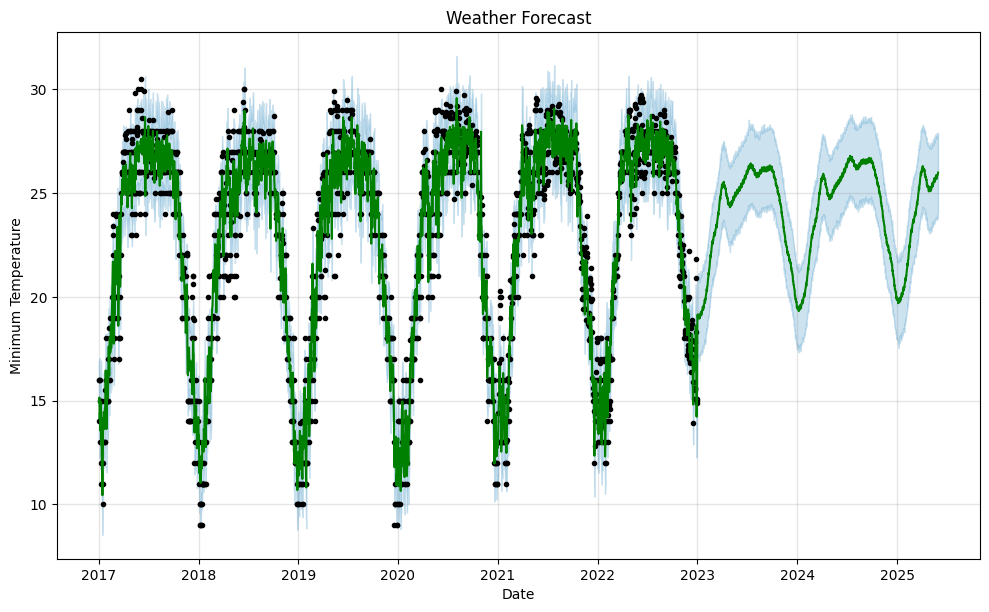

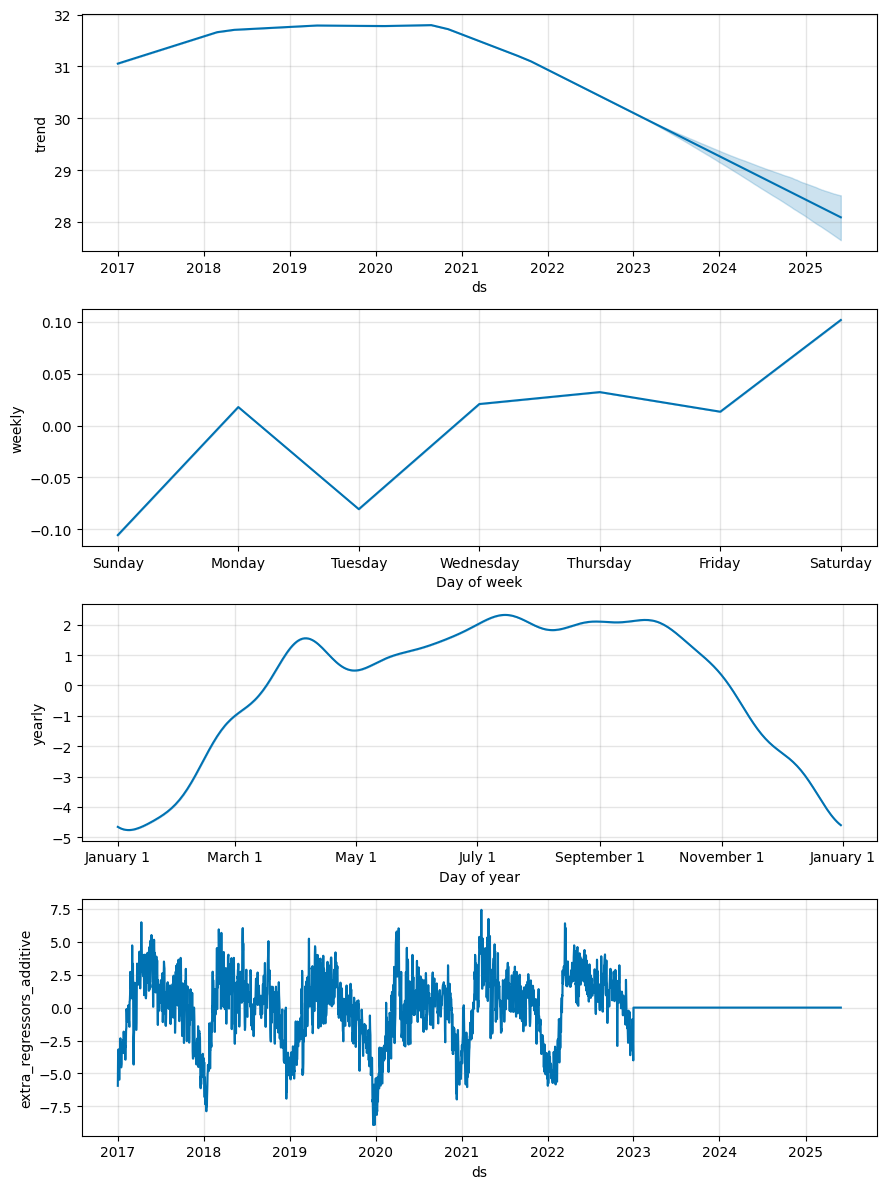

In [ ]:
# Plot the forecast
fig = model.plot(forecast_min)
plt.title('Weather Forecast')
plt.xlabel('Date')
plt.ylabel('Minimum Temperature')

# Get the line representing the forecast (usually the second line in the plot)
forecast_line = fig.axes[0].lines[1]

# Change the color of the forecast line
forecast_line.set_color('green')
plt.show()

# Plot components (trend, seasonality)
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
from prophet import Prophet


# Prepare data for Prophet
# Create a copy of the DataFrame to avoid modifying the original df in place
prophet_hum_df = df.copy()

# Reset the index to make 'Date' a regular column again
prophet_hum_df = prophet_hum_df.reset_index()

# Rename columns for Prophet
prophet_hum_df = prophet_hum_df.rename(columns={'Date': 'ds', 'Relative Humidity': 'y'})  # Prophet expects 'ds' and 'y' columns

# Add other features as regressors to the Prophet DataFrame
prophet_hum_df['MaxTemp'] = prophet_hum_df['Maximum Temperature']
prophet_hum_df['MinTemp'] = prophet_hum_df['Minimum Temperature']
prophet_hum_df['Pressure'] = prophet_hum_df['Sea Level Pressure']

# Select only the required columns for Prophet
prophet_hum_df = prophet_hum_df[['ds', 'y', 'MaxTemp', 'MinTemp', 'Pressure']]


# Create and train the model
model = Prophet()
model.add_regressor('MaxTemp')
model.add_regressor('MinTemp')
model.add_regressor('Pressure')
model.fit(prophet_hum_df) # Fit the model using the prepared DataFrame

# Create future dates for forecasting
future_hum = model.make_future_dataframe(periods=882)  # Forecast for the next 2.5 year

# Add the regressors to the future DataFrame by merging with the prophet_df
future_hum = pd.merge(future_hum, prophet_hum_df[['ds', 'MaxTemp', 'MinTemp', 'Pressure']], on='ds', how='left')

# Fill NaN values in the future DataFrame with the mean of the respective columns from prophet_df
future_hum = future_hum.fillna(prophet_hum_df[['MaxTemp', 'MinTemp', 'Pressure']].mean())

# Make predictions
forecast_hum = model.predict(future_hum)


# Access forecast values
print(forecast_hum[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))  # View the last 30 days

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/h6e2xo9f.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/stajugv9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=71213', 'data', 'file=/tmp/tmp6mm4_nvm/h6e2xo9f.json', 'init=/tmp/tmp6mm4_nvm/stajugv9.json', 'output', 'file=/tmp/tmp6mm4_nvm/prophet_model3kzh_uuy/prophet_model-20250524062335.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:23:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:23:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


             ds       yhat  yhat_lower  yhat_upper
3043 2025-05-02  56.776712   47.002683   66.355004
3044 2025-05-03  56.497767   46.444103   66.252270
3045 2025-05-04  57.123073   47.773885   65.659259
3046 2025-05-05  57.146476   47.737021   65.965629
3047 2025-05-06  57.888700   47.931297   67.575915
3048 2025-05-07  57.771397   48.315166   67.142966
3049 2025-05-08  57.812762   48.082825   67.637691
3050 2025-05-09  57.753893   48.955214   66.798447
3051 2025-05-10  57.413145   47.702185   66.565481
3052 2025-05-11  57.959867   48.414126   67.085731
3053 2025-05-12  57.889411   48.613833   66.912888
3054 2025-05-13  58.524502   48.935654   68.296220
3055 2025-05-14  58.289216   49.121300   67.578043
3056 2025-05-15  58.204532   48.035280   67.744366
3057 2025-05-16  58.014605   48.485325   67.823017
3058 2025-05-17  57.541040   47.510549   67.122260
3059 2025-05-18  57.956523   48.425868   67.107135
3060 2025-05-19  57.759745   47.860631   66.939643
3061 2025-05-20  58.276667   48

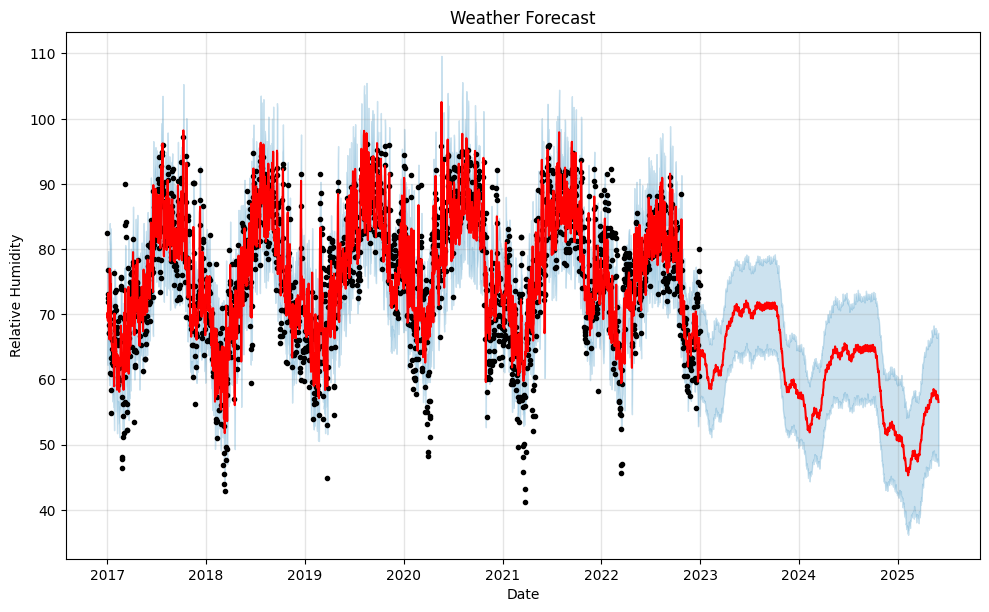

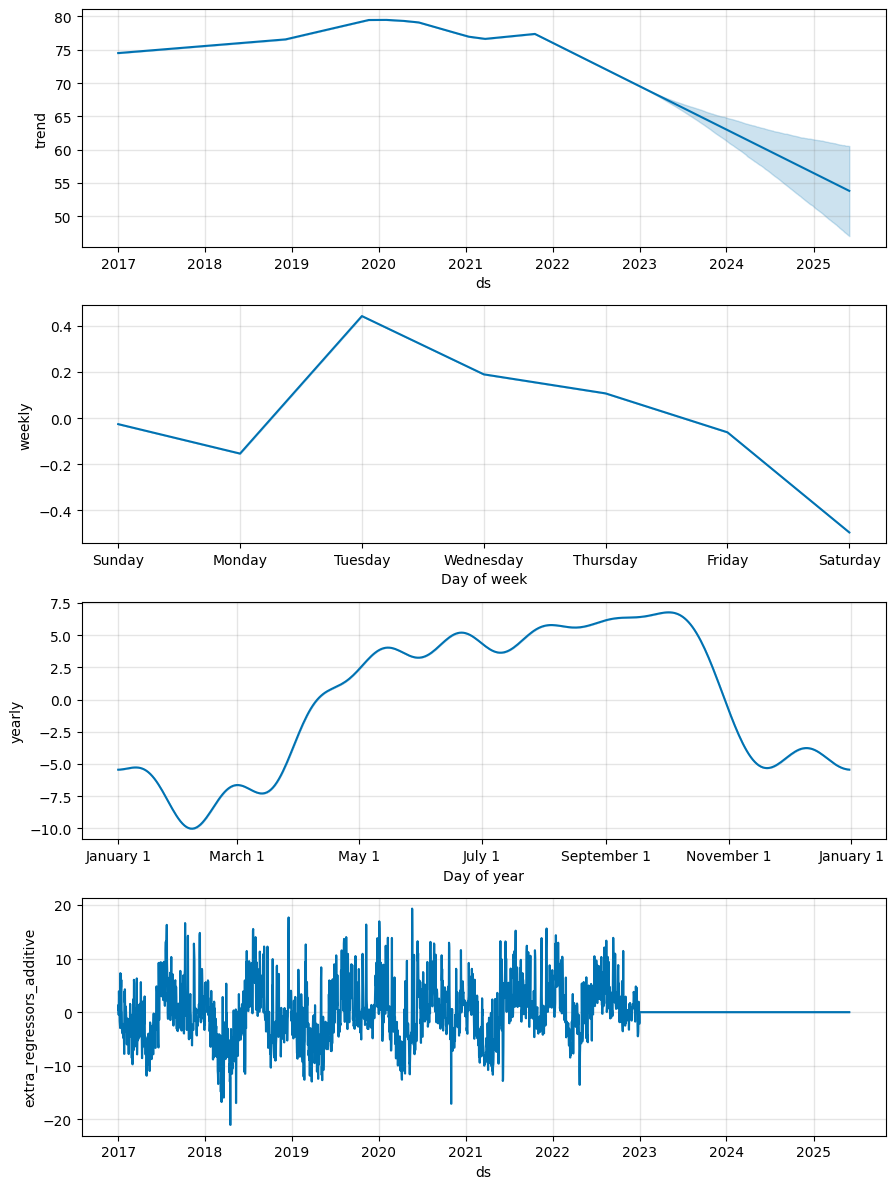

In [ ]:
# Plot the forecast
fig = model.plot(forecast_hum)
plt.title('Weather Forecast')
plt.xlabel('Date')
plt.ylabel('Relative Humidity')

# Get the line representing the forecast (usually the second line in the plot)
forecast_line = fig.axes[0].lines[1]

# Change the color of the forecast line
forecast_line.set_color('red')
plt.show()

# Plot components (trend, seasonality)
fig2 = model.plot_components(forecast_hum)
plt.show()

In [ ]:
from prophet import Prophet


# Prepare data for Prophet
# Create a copy of the DataFrame to avoid modifying the original df in place
prophet_prs_df = df.copy()

# Reset the index to make 'Date' a regular column again
prophet_prs_df = prophet_prs_df.reset_index()

# Rename columns for Prophet
prophet_prs_df = prophet_prs_df.rename(columns={'Date': 'ds', 'Sea Level Pressure': 'y'})  # Prophet expects 'ds' and 'y' columns

# Add other features as regressors to the Prophet DataFrame
prophet_prs_df['MaxTemp'] = prophet_prs_df['Maximum Temperature']
prophet_prs_df['MinTemp'] = prophet_prs_df['Minimum Temperature']
prophet_prs_df['Humidity'] = prophet_prs_df['Relative Humidity']

# Select only the required columns for Prophet
prophet_prs_df = prophet_prs_df[['ds', 'y', 'MaxTemp', 'MinTemp', 'Humidity']]


# Create and train the model
model = Prophet()
model.add_regressor('MaxTemp')
model.add_regressor('MinTemp')
model.add_regressor('Humidity')
model.fit(prophet_prs_df) # Fit the model using the prepared DataFrame

# Create future dates for forecasting
future_prs = model.make_future_dataframe(periods=882)  # Forecast for the next 2.5 year

# Add the regressors to the future DataFrame by merging with the prophet_df
future_prs = pd.merge(future_prs, prophet_prs_df[['ds', 'MaxTemp', 'MinTemp', 'Humidity']], on='ds', how='left')

# Fill NaN values in the future DataFrame with the mean of the respective columns from prophet_df
future_prs = future_prs.fillna(prophet_prs_df[['MaxTemp', 'MinTemp', 'Humidity']].mean())

# Make predictions
forecast_prs = model.predict(future_prs)


# Access forecast values
print(forecast_prs[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))  # View the last 30 days

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/niblippy.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6mm4_nvm/g2rt_g9v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=93129', 'data', 'file=/tmp/tmp6mm4_nvm/niblippy.json', 'init=/tmp/tmp6mm4_nvm/g2rt_g9v.json', 'output', 'file=/tmp/tmp6mm4_nvm/prophet_model6hp9izzp/prophet_model-20250524062415.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:24:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:24:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


             ds         yhat  yhat_lower   yhat_upper
3043 2025-05-02  1004.540353  965.872698  1044.170525
3044 2025-05-03  1004.430035  965.444588  1042.682561
3045 2025-05-04  1004.352339  965.333211  1043.341015
3046 2025-05-05  1004.207206  965.470084  1044.124412
3047 2025-05-06  1004.158796  964.966961  1043.464089
3048 2025-05-07  1004.091731  964.806083  1043.970259
3049 2025-05-08  1004.044187  965.015768  1043.304381
3050 2025-05-09  1003.800829  964.040484  1042.921706
3051 2025-05-10  1003.614788  964.299107  1043.731081
3052 2025-05-11  1003.464148  964.108160  1043.536347
3053 2025-05-12  1003.250157  963.625467  1044.068343
3054 2025-05-13  1003.138197  963.533859  1043.546553
3055 2025-05-14  1003.013995  963.226712  1042.461557
3056 2025-05-15  1002.916700  963.286732  1043.254205
3057 2025-05-16  1002.631787  963.253953  1042.589731
3058 2025-05-17  1002.413025  962.065207  1042.899647
3059 2025-05-18  1002.238951  961.966811  1042.328870
3060 2025-05-19  1002.011072

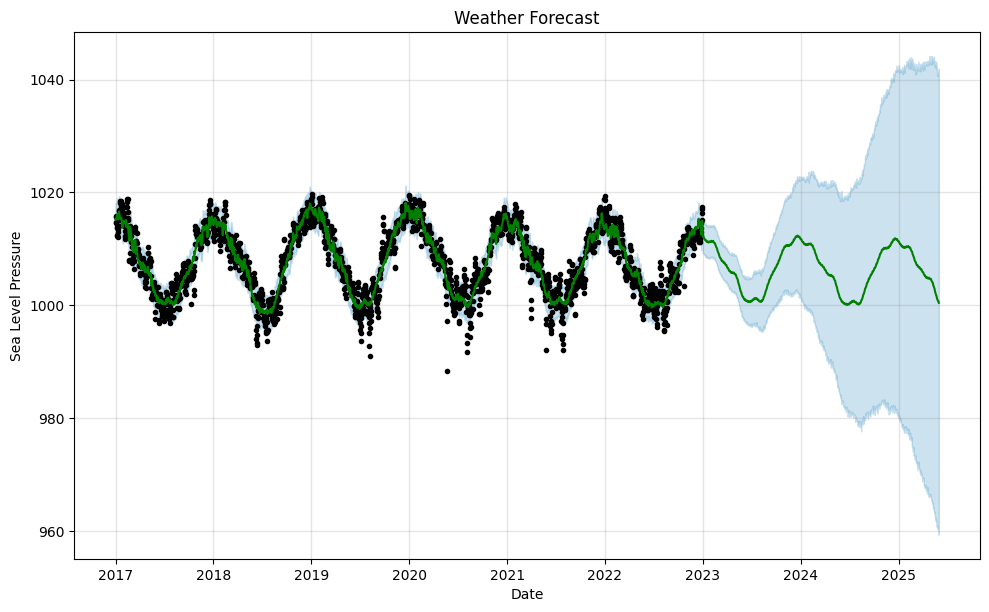

In [ ]:
# Plot the forecast
fig = model.plot(forecast_prs)
plt.title('Weather Forecast')
plt.xlabel('Date')
plt.ylabel('Sea Level Pressure')

# Get the line representing the forecast (usually the second line in the plot)
forecast_line = fig.axes[0].lines[1]

# Change the color of the forecast line
forecast_line.set_color('green')
plt.show()

In [ ]:
# Assuming 'actual_data' is the DataFrame with actual values for the forecast period
# It should have a 'Date' column (datetime objects) and the actual value columns

# Rename the date column in actual_data to 'ds' to match forecast dataframes
sdf = sdf.rename(columns={'Date': 'ds'})

# Merge forecast dataframes with actual_data

# Maximum Temperature comparison
max_temp_comparison = pd.merge(forecast[['ds', 'yhat']], sdf[['ds', 'maxtemp']], on='ds', how='inner')
max_temp_comparison = max_temp_comparison.rename(columns={'yhat': 'Predicted Max Temp', 'maxtemp': 'Actual Max Temp'})
print("Maximum Temperature Comparison:")
print(max_temp_comparison.tail())

# Minimum Temperature comparison
min_temp_comparison = pd.merge(forecast_min[['ds', 'yhat']], sdf[['ds', 'mintemp']], on='ds', how='inner')
min_temp_comparison = min_temp_comparison.rename(columns={'yhat': 'Predicted Min Temp', 'mintemp': 'Actual Min Temp'})
print("\nMinimum Temperature Comparison:")
print(min_temp_comparison.tail())

# Relative Humidity comparison
hum_comparison = pd.merge(forecast_hum[['ds', 'yhat']], sdf[['ds', 'Hum']], on='ds', how='inner')
hum_comparison = hum_comparison.rename(columns={'yhat': 'Predicted Humidity', 'Hum': 'Actual Humidity'})
print("\nRelative Humidity Comparison:")
print(hum_comparison.tail())

# Sea Level Pressure comparison
prs_comparison = pd.merge(forecast_prs[['ds', 'yhat']], sdf[['ds', 'pressure']], on='ds', how='inner')
prs_comparison = prs_comparison.rename(columns={'yhat': 'Predicted Pressure', 'pressure': 'Actual Pressure'})
print("\nSea Level Pressure Comparison:")
print(prs_comparison.tail())

Maximum Temperature Comparison:
           ds  Predicted Max Temp  Actual Max Temp
48 2025-03-21           28.450471             34.2
49 2025-03-27           28.650463             33.9
50 2025-04-02           28.986932             35.2
51 2025-04-03           29.014684             35.6
52 2025-04-04           29.146158             32.8

Minimum Temperature Comparison:
           ds  Predicted Min Temp  Actual Min Temp
48 2025-03-21           25.075009            20.97
49 2025-03-27           25.733574            22.50
50 2025-04-02           26.145383            23.20
51 2025-04-03           26.192340            24.20
52 2025-04-04           26.197613            26.30

Relative Humidity Comparison:
           ds  Predicted Humidity  Actual Humidity
48 2025-03-21           48.560766             47.0
49 2025-03-27           50.530222             29.2
50 2025-04-02           52.785508             61.0
51 2025-04-03           53.036351             54.0
52 2025-04-04           53.183195    

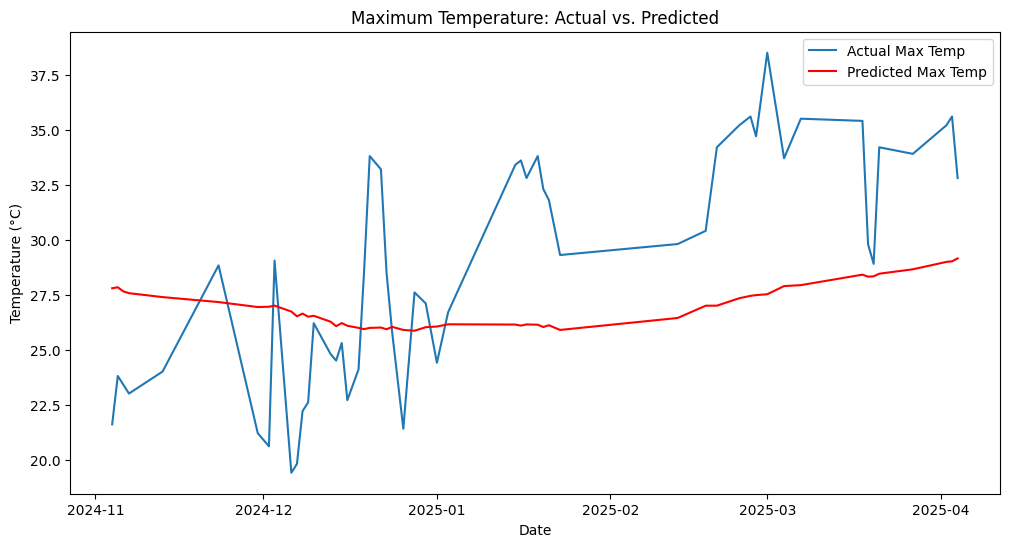

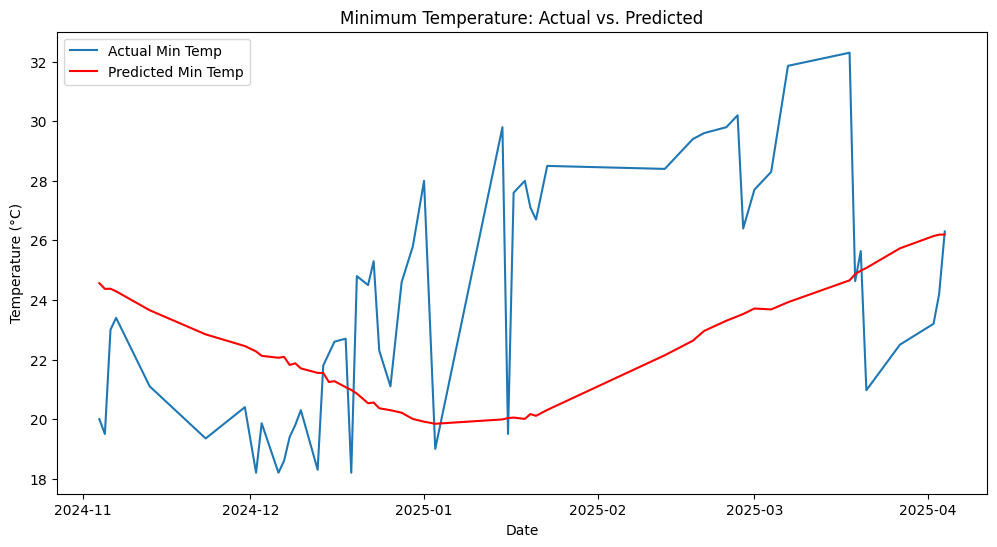

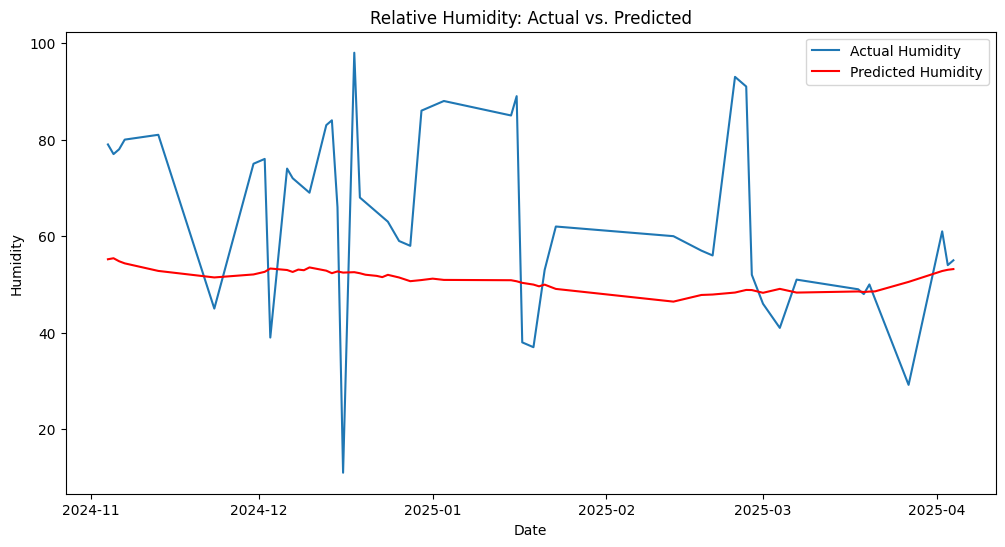

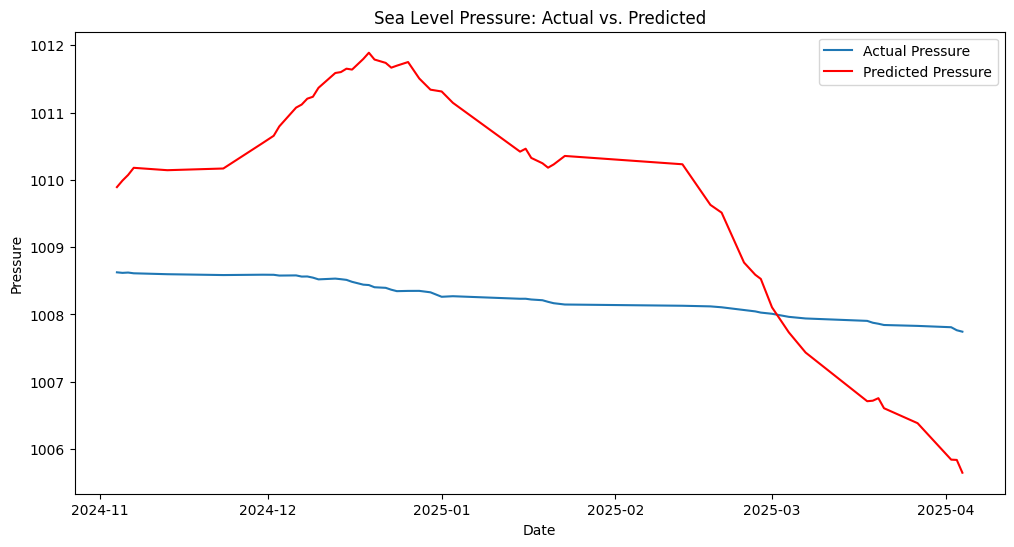

In [ ]:
# Plot Maximum Temperature comparison
plt.figure(figsize=(12, 6))
plt.plot(max_temp_comparison['ds'], max_temp_comparison['Actual Max Temp'], label='Actual Max Temp')
plt.plot(max_temp_comparison['ds'], max_temp_comparison['Predicted Max Temp'], label='Predicted Max Temp', color='red')
plt.title('Maximum Temperature: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# Plot Minimum Temperature comparison
plt.figure(figsize=(12, 6))
plt.plot(min_temp_comparison['ds'], min_temp_comparison['Actual Min Temp'], label='Actual Min Temp')
plt.plot(min_temp_comparison['ds'], min_temp_comparison['Predicted Min Temp'], label='Predicted Min Temp', color='red')
plt.title('Minimum Temperature: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

# Plot Relative Humidity comparison
plt.figure(figsize=(12, 6))
plt.plot(hum_comparison['ds'], hum_comparison['Actual Humidity'], label='Actual Humidity')
plt.plot(hum_comparison['ds'], hum_comparison['Predicted Humidity'], label='Predicted Humidity', color='red')
plt.title('Relative Humidity: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Humidity')
plt.legend()
plt.show()

# Plot Sea Level Pressure comparison
plt.figure(figsize=(12, 6))
plt.plot(prs_comparison['ds'], prs_comparison['Actual Pressure'], label='Actual Pressure')
plt.plot(prs_comparison['ds'], prs_comparison['Predicted Pressure'], label='Predicted Pressure', color='red')
plt.title('Sea Level Pressure: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Pressure')
plt.legend()
plt.show()

---